In [1]:
import torch
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from libs import TransformerModel, Loader, Solver, Trainer
from libs.constants import *
from libs.utils import NDCG, count_polars, count_params, sample_polars

In [2]:
EMB_DIM = 16
NUM_RECENT_VIDEOS = 150
TEST_ITEMS = 5_000

In [3]:
loader = Loader('ur0.01_ir0.01', content_embedding_size=EMB_DIM, val_weeks=1, batch_size=500_000)
((train_df, val_df), test_df), users_df, items_df = loader.load_data(convert_to_pandas=False)

Load metadata
Create lazy interaction datasets
Get unique users/items


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Filter embeddings
Process metadata
Compute aggregates


  0%|          | 0/8 [00:00<?, ?it/s]

Filter interactions
Finalize interactions
Count
Train: 58_231 Val: 11_874 Test: 9_396 Users: 2_185 Items: 117_060


In [4]:
train_df: pl.LazyFrame = train_df.filter(pl.col(TARGET) > 0)  # Interaction: positive
val_df: pl.LazyFrame = val_df.filter(pl.col(TARGET) > 0)  # Interaction: positive
test_df: pl.LazyFrame = test_df.filter(pl.col(TARGET) > 0)  # Interaction: positive

print(f"Train: {count_polars(train_df):_} Val: {count_polars(val_df):_} Test: {count_polars(test_df):_}")

Train: 58_119 Val: 1_869 Test: 1_535


In [5]:
model = TransformerModel(
    in_dim=EMB_DIM,
    hidden_dim=128,
    num_layers=3,
    nheads=8,
    dim_feedforward=256,
    dropout=0.5,
    trainable_position=False,
    max_seq_len=NUM_RECENT_VIDEOS,
)
# TODO add target encoding
# TODO target as target
# TODO add initial user embedding
# TODO CrossEntropy


# model = RNNModel(
#     in_dim=EMB_DIM,
#     hidden_dim=128,
#     layer='lstm',
#     num_layers=2,
#     dropout=0.5,
# )

# model = WeightedAvgModel(
#     method='add',
#     temporal_distribution='linear',
#     alpha=0.5,
# )

print(f"Params: {count_params(model):_}")

Params: 420_736


In [6]:
trainer = Trainer(
    model=model,
    train_interactions=train_df,
    val_interactions=val_df,
    items_metadata=items_df,
    loss_type='cos',
    loss_margin=0.1,
    negative_ratio=5,
    num_recent_videos=NUM_RECENT_VIDEOS,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)

Count
Users: All: 2_185 Train: 2_185 Val: 927


In [ ]:
trainer.fit(epochs=5, users_batch_size=192, verbose=True)

In [7]:
trainer.load_checkpoint()

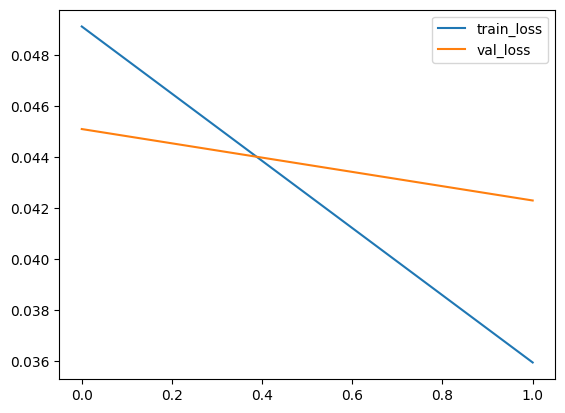

In [10]:
plt.plot(np.arange(len(list(trainer.history.values())[0])), *trainer.history.values())
plt.legend(trainer.history.keys())

In [8]:
test_items = test_df.select(ITEM).unique(ITEM)
count_items = count_polars(test_items)

test = sample_polars(test_items, n_rows=TEST_ITEMS, id_columns=[ITEM])
cold_test = test.join(train_df.select(ITEM).unique(), on=ITEM, how="anti")

print(f"Test items: {count_polars(test)} Test cold items: {count_polars(cold_test)}")

Test items: 924 Test cold items: 169


In [9]:
solver = Solver(
    trainer=trainer,
    predict_items=test,
    candidates_to_keep=500,
    top_per_item=100,
    max_per_user=100,
)
trainer.model.eval()
solver.collect_candidates(users_batch_size=512, items_batch_size=2048)

Users:   0%|          | 0/44 [00:00<?, ?it/s]

Score Items:   0%|          | 0/5000 [00:00<?, ?it/s]

Predict Items:   0%|          | 0/3 [00:00<?, ?it/s]

Clean up:   0%|          | 0/5000 [00:00<?, ?it/s]

In [10]:
results = solver.solve()

predict = pl.DataFrame({
    ITEM: list(results.keys()),
    USER: [[u for u, _ in users_scores] for users_scores in results.values()]
})

In [14]:
for true, true_name in [
    (test_df.join(test, on=ITEM, how='inner'), "all"),
    (test_df.join(cold_test, on=ITEM, how='inner'), "cold")
]:
    true_agg = true.group_by(ITEM).agg(pl.col(USER)).collect()
    print(f"Test: {true_name} "
          f"Size: {true_agg.select(pl.len()).item()} "
          f"NDCG: {NDCG(predict.to_pandas(),true_agg.to_pandas()):.4f}")

Test: all Size: 5000 NDCG: 0.0144
Test: cold Size: 661 NDCG: 0.0171
